1.Ingestion of the Data

In [15]:
import pandas as pd

df = pd.read_csv('../data/fake_or_real_news.csv')

print("Data Imported Succesfully")

Data Imported Succesfully


In [16]:
print(df.shape)
print("Ther dimension of the data:-")

(6335, 4)
Ther dimension of the data:-


In [17]:
print(df.head())
print("The Starting rows of the Data")

      id                                              title  \
0   8476                       You Can Smell Hillary’s Fear   
1  10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2   3608        Kerry to go to Paris in gesture of sympathy   
3  10142  Bernie supporters on Twitter erupt in anger ag...   
4    875   The Battle of New York: Why This Primary Matters   

                                                text label  
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2  U.S. Secretary of State John F. Kerry said Mon...  REAL  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4  It's primary day in New York and front-runners...  REAL  
The Starting rows of the Data


In [18]:
df['label'].value_counts()

label
REAL    3171
FAKE    3164
Name: count, dtype: int64

2.Punctuation Removal,Lowercase Transformation, Removing Extra Whitespaces

In [19]:
# Importing Needed Libraries
import re
import string

def clean_text(text):
    text = text.lower()
    # Remove Puntuation(Using str.transalte with str.maketrans())
    text.translate(str.maketrans('', '', string.punctuation))
    # Remove Whitespaces(re.sub{Regex Substitute})
    re.sub(r'\s+', ' ', text).strip()
    return text

In [20]:
# Now on Checking 
print(df['title'][0])
print(clean_text(df['title'][0]))

You Can Smell Hillary’s Fear
you can smell hillary’s fear


In [21]:
df['content'] = (df['title'] + ' ' + df['text']).apply(clean_text)
df[['content', 'label']].head()

,content,label
0,you can smell hillary’s fear daniel greenfield...,FAKE
1,watch the exact moment paul ryan committed pol...,FAKE
2,kerry to go to paris in gesture of sympathy u....,REAL
3,bernie supporters on twitter erupt in anger ag...,FAKE
4,the battle of new york: why this primary matte...,REAL


3. Train-Test-Split

In [22]:
from sklearn.model_selection import train_test_split

X = df['content']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
''' Here are some points that needs to be noticed:-
1. test_size=0.2  is the size of the data we are using for testing as we can see (20%) of data is used for testing while the remaining (80%) will be used for training
2. Random_state=42 it makes splits reproducible 
3. Stratify=y it is very important factor within itself it ensures that train and test sets each preserve the same Fake/Real ratio as the original set'''

' Here are some points that needs to be noticed:-\n1. test_size=0.2  is the size of the data we are using for testing as we can see (20%) of data is used for testing while the remaining (80%) will be used for training\n2. Random_state=42 it makes splits reproducible \n3. Stratify=y it is very important factor within itself it ensures that train and test sets each preserve the same Fake/Real ratio as the original set'

In [23]:
# On checking the split sizes
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 5068, Test size: 1267


4.TF-IDF Vectorization

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_df=0.7, max_features=50000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [25]:
# Now testing the Vectorization
print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")

TF-IDF matrix shape (train): (5068, 50000)


In [26]:
from sklearn.linear_model import PassiveAggressiveClassifier
model=PassiveAggressiveClassifier(max_iter=50,random_state=42)
model.fit(X_train_tfidf, y_train)

c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


,"C C: float, default=1.0Aggressiveness parameter for the passive-agressive algorithm, see [1].For PA-I it is the maximum step size. For PA-II it regularizes thestep size (the smaller `C` the more it regularizes).As a general rule-of-thumb, `C` should be small when the data is noisy.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`~sklearn.linear_model.PassiveAggressiveClassifier.partial_fit` method... versionadded:: 0.19",50
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically set asidea stratified fraction of training data as validation and terminatetraining when validation score is not improving by at least `tol` for`n_iter_no_change` consecutive epochs... versionadded:: 0.20",False
,"validation_fraction validation_fraction: float, default=0.1The proportion of training data to set aside as validation set forearly stopping. Must be between 0 and 1.Only used if early_stopping is True... versionadded:: 0.20",0.1
,"n_iter_no_change n_iter_no_change: int, default=5Number of iterations with no improvement to wait before early stopping... versionadded:: 0.20",5
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"loss loss: str, default=""hinge""The loss function to be used:hinge: equivalent to PA-I in the reference paper.squared_hinge: equivalent to PA-II in the reference paper.",'hinge'
,"n_jobs n_jobs: int or None, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


5. Model Accuracy Test

In [27]:
from sklearn.metrics import accuracy_score
preds = model.predict(X_test_tfidf)
acc = accuracy_score(y_test, preds)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9432


6. Classification report

In [28]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

        FAKE       0.94      0.95      0.94       633
        REAL       0.95      0.94      0.94       634

    accuracy                           0.94      1267
   macro avg       0.94      0.94      0.94      1267
weighted avg       0.94      0.94      0.94      1267



7.Confusion Matrix Visualization

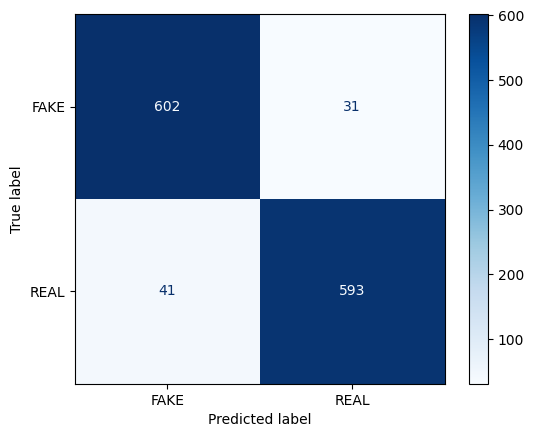

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.show()

8.Saving the model

In [32]:
import joblib

joblib.dump(model, '../models/fake_news_model.pkl')
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')

['../models/tfidf_vectorizer.pkl']